# H4P2 — LDI Bin Comparison Within Each Condition

Hypothesis: within each condition (`item_only`, `task_only`, `both_item_task`), LDI changes across lure-similarity bins.

This notebook computes bin-wise LDI separately for each condition, then runs paired one-sided t-tests on adjacent bins (`Bin2 > Bin1`, `Bin3 > Bin2`, `Bin4 > Bin3`, `Bin5 > Bin4`) with Holm correction applied **within each condition**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ttest_rel
from statsmodels.stats.multitest import multipletests

sns.set(style='whitegrid', context='talk')

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / '01_Preprocessing' / 'compiled_preprocessed.csv').exists():
            return path
    raise FileNotFoundError('Could not locate project root containing 01_Preprocessing/compiled_preprocessed.csv')

ROOT = find_project_root()
df = pd.read_csv(ROOT / '01_Preprocessing' / 'compiled_preprocessed.csv')
df['condition'] = df['condition'].astype(str).str.strip().str.lower()

if 'participant_uid' in df.columns:
    df['participant_key'] = df['participant_uid'].astype(str)
else:
    df['participant_key'] = df['condition'].astype(str) + '_' + df['participant_id'].astype(str)

display(df[['participant_key', 'participant_id', 'condition']].drop_duplicates().groupby('condition').size().rename('n_participants').to_frame())

,n_participants
condition,
both_item_task,51
item_only,56
task_only,53


In [2]:
def load_map(path):
    out = {}
    for line in Path(path).read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        idx, b = line.strip().split()[:2]
        out[int(idx)] = int(b)
    return out

condition_maps = {
    'item_only': {
        'kind': 'split',
        'set6': load_map(ROOT / 'MAIN_DATA' / 'MST_Data' / 'item_only' / 'Set6 bins.txt'),
        'setsc': load_map(ROOT / 'MAIN_DATA' / 'MST_Data' / 'item_only' / 'SetScC bins.txt'),
    },
    'both_item_task': {
        'kind': 'split',
        'set6': load_map(ROOT / 'MAIN_DATA' / 'MST_Data' / 'Both_item_task' / 'Set6 bins.txt'),
        'setsc': load_map(ROOT / 'MAIN_DATA' / 'MST_Data' / 'Both_item_task' / 'SetScC bins.txt'),
    },
    'task_only': {
        'kind': 'direct',
        'map': load_map(ROOT / 'MAIN_DATA' / 'MST_Data' / 'task_only' / 'Set6 bins_ob.txt'),
    },
}

def infer_bin(image_path, condition):
    x = pd.to_numeric(pd.Series([image_path]).str.extract(r'(\d+)')[0], errors='coerce').iloc[0]
    if pd.isna(x):
        return np.nan

    x = int(x)
    condition = str(condition).strip().lower()
    spec = condition_maps.get(condition)
    if spec is None:
        return np.nan

    if spec['kind'] == 'split':
        if 1 <= x <= 192:
            return spec['set6'].get(x, np.nan)
        if 193 <= x <= 384:
            return spec['setsc'].get(x - 192, np.nan)
        return np.nan

    if spec['kind'] == 'direct':
        if 1 <= x <= 384:
            return spec['map'].get(x, np.nan)
        return np.nan

    return np.nan

map_summary = []
for condition, spec in condition_maps.items():
    if spec['kind'] == 'split':
        map_summary.append({
            'condition': condition,
            'mapping_type': 'split',
            'set6_items': len(spec['set6']),
            'setsc_items': len(spec['setsc'])
        })
    else:
        map_summary.append({
            'condition': condition,
            'mapping_type': 'direct',
            'set6_items': len(spec['map']),
            'setsc_items': np.nan
        })

display(pd.DataFrame(map_summary))

,condition,mapping_type,set6_items,setsc_items
0,item_only,split,192,192.0
1,both_item_task,split,192,192.0
2,task_only,direct,384,NaN


In [3]:
lure = df[df['trial_type'] == 'Lure'].copy()
lure['lure_bin'] = lure.apply(lambda row: infer_bin(row['image_path'], row['condition']), axis=1)

foil_base = (
    df[df['trial_type'] == 'Foil']
    .groupby(['participant_key', 'participant_id', 'condition'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('foil_sim')
    .reset_index()
)

bin_df = (
    lure[lure['lure_bin'].notna()]
    .groupby(['participant_key', 'participant_id', 'condition', 'lure_bin'])['user_response']
    .apply(lambda s: (s == 'Lure').mean())
    .rename('lure_sim')
    .reset_index()
    .merge(foil_base, on=['participant_key', 'participant_id', 'condition'], how='left')
)

bin_df['LDI_bin'] = bin_df['lure_sim'] - bin_df['foil_sim']
display(bin_df.head())

,participant_key,participant_id,condition,lure_bin,lure_sim,foil_sim,LDI_bin
0,both_item_task_both_item_task_00015,both_item_task_00015,both_item_task,1,0.625000,0.166667,0.458333
1,both_item_task_both_item_task_00015,both_item_task_00015,both_item_task,2,0.200000,0.166667,0.033333
2,both_item_task_both_item_task_00015,both_item_task_00015,both_item_task,3,0.200000,0.166667,0.033333
3,both_item_task_both_item_task_00015,both_item_task_00015,both_item_task,4,0.611111,0.166667,0.444444
4,both_item_task_both_item_task_00015,both_item_task_00015,both_item_task,5,0.222222,0.166667,0.055556


In [4]:
pairs = [(2, 1), (3, 2), (4, 3), (5, 4)]

def paired_greater_test(x, y):
    mask = x.notna() & y.notna()
    n = int(mask.sum())
    if n < 2:
        return n, np.nan, np.nan
    test = ttest_rel(x[mask], y[mask], alternative='greater')
    return n, test.statistic, test.pvalue

complete_counts = []
mean_rows = []
result_tables = []

for condition in sorted(bin_df['condition'].dropna().unique()):
    cond_df = bin_df[bin_df['condition'] == condition].copy()
    wide = cond_df.pivot(index='participant_key', columns='lure_bin', values='LDI_bin')
    wide = wide.reindex(columns=[1, 2, 3, 4, 5])
    wide_complete = wide.dropna()

    complete_counts.append({
        'condition': condition,
        'complete_participants': len(wide_complete)
    })

    for bin_no in [1, 2, 3, 4, 5]:
        mean_rows.append({
            'condition': condition,
            'bin': bin_no,
            'mean_ldi': wide_complete[bin_no].mean()
        })

    tests = []
    for a, b in pairs:
        n, t_stat, p_raw = paired_greater_test(wide_complete[a], wide_complete[b])
        tests.append({
            'condition': condition,
            'comparison': f'Bin{a} > Bin{b}',
            'n_pairs': n,
            'mean_diff': (wide_complete[a] - wide_complete[b]).mean(),
            't_stat': t_stat,
            'p_raw': p_raw
        })

    res = pd.DataFrame(tests)
    valid = res['p_raw'].notna()
    res['p_adj_holm'] = np.nan
    if valid.any():
        res.loc[valid, 'p_adj_holm'] = multipletests(res.loc[valid, 'p_raw'], method='holm')[1]
    res['supported (adj p<.05)'] = res['p_adj_holm'] < 0.05
    result_tables.append(res)

complete_df = pd.DataFrame(complete_counts)
means_df = pd.DataFrame(mean_rows)
result_df = pd.concat(result_tables, ignore_index=True)

display(complete_df)
display(means_df.pivot(index='condition', columns='bin', values='mean_ldi'))
display(result_df.sort_values(['condition', 'comparison']))

,condition,complete_participants
0,both_item_task,51
1,item_only,56
2,task_only,53


bin,1,2,3,4,5
condition,,,,,
both_item_task,0.209308,0.272157,0.249152,0.312291,0.301739
item_only,0.264051,0.338888,0.314419,0.340621,0.349092
task_only,0.248531,0.343748,0.396418,0.444600,0.471346


,condition,comparison,n_pairs,mean_diff,t_stat,p_raw,p_adj_holm,supported (adj p<.05)
0,both_item_task,Bin2 > Bin1,51,0.062849,2.096390,0.020564,0.061693,False
1,both_item_task,Bin3 > Bin2,51,-0.023005,-0.883253,0.809337,1.000000,False
2,both_item_task,Bin4 > Bin3,51,0.063140,2.379510,0.010596,0.042385,True
3,both_item_task,Bin5 > Bin4,51,-0.010553,-0.443626,0.670387,1.000000,False
4,item_only,Bin2 > Bin1,56,0.074838,2.833728,0.003210,0.012842,True
5,item_only,Bin3 > Bin2,56,-0.024469,-0.932562,0.822439,0.822439,False
6,item_only,Bin4 > Bin3,56,0.026201,1.092076,0.139780,0.419341,False
7,item_only,Bin5 > Bin4,56,0.008471,0.288751,0.386929,0.773857,False
8,task_only,Bin2 > Bin1,53,0.095218,3.671703,0.000285,0.001138,True
9,task_only,Bin3 > Bin2,53,0.052670,1.973284,0.026894,0.080683,False


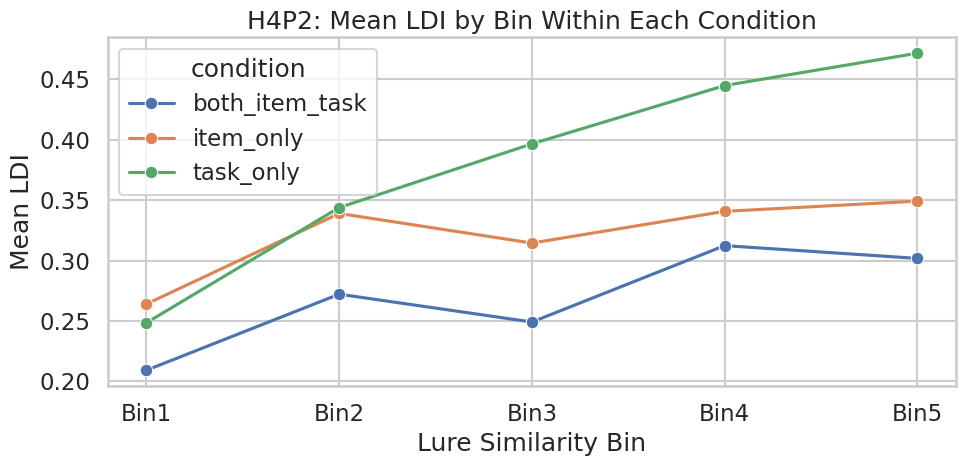

In [5]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=means_df, x='bin', y='mean_ldi', hue='condition', marker='o')
plt.xticks([1, 2, 3, 4, 5], [f'Bin{i}' for i in [1, 2, 3, 4, 5]])
plt.title('H4P2: Mean LDI by Bin Within Each Condition')
plt.xlabel('Lure Similarity Bin')
plt.ylabel('Mean LDI')
plt.tight_layout()
plt.show()

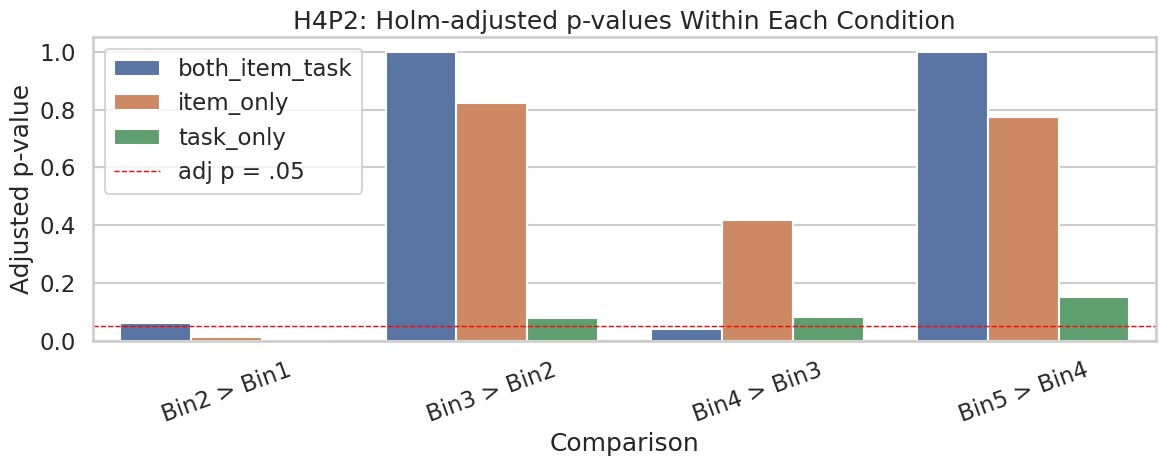

In [6]:
p_plot = result_df.dropna(subset=['p_adj_holm']).copy()
plt.figure(figsize=(12, 5))
sns.barplot(data=p_plot, x='comparison', y='p_adj_holm', hue='condition')
plt.axhline(0.05, color='red', linestyle='--', linewidth=1, label='adj p = .05')
plt.title('H4P2: Holm-adjusted p-values Within Each Condition')
plt.xlabel('Comparison')
plt.ylabel('Adjusted p-value')
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

### Why we are seeing this behavior (interpretation)

- **Task-only shows the clearest monotonic increase** from Bin1 to Bin5, which suggests lure-similarity manipulations are strongest when participants focus on task features without item-context competition.
- **Both-item-task and item-only show flatter / non-monotonic middle bins** (especially around Bin3), indicating overlap between adjacent bins and higher trial-level noise in intermediate similarity levels.
- **Early contrast (Bin2 > Bin1) is strongest and most reliable** because the jump from the easiest bin often produces the largest effect size.
- **Later adjacent contrasts are smaller** (e.g., Bin3→Bin4 or Bin4→Bin5), so even when raw p-values are < .05, they often fail after Holm correction.
- **Holm adjustment across 4 within-condition tests is conservative**, so only the most robust comparisons survive.
- **Practical implication:** the data support a graded LDI pattern most clearly in task-only, while item-related conditions likely need either larger N or wider bin separation to detect all adjacent-bin steps.